In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("fact_nav.csv")
transactions = pd.read_csv("fact_transactions.csv")
performance = pd.read_csv("fact_performance.csv")
scorecard = pd.read_csv("fund_scorecard.csv")

In [18]:
import os
print(os.listdir())

['advanced_analytics.ipynb', 'app.py', 'bluestock_mf.pbix', 'cagr.csv', 'cohort_analysis.csv', 'correlation_heatmap.png', 'eda_analysis.ipynb', 'fact_nav.csv', 'fact_performance.csv', 'fact_transactions.csv', 'fund_scorecard.csv', 'max_drawdown.csv', 'performance_analysis.ipynb', 'rolling_sharpe_chart.png', 'sector_hhi.csv', 'sharpe_ratio.csv', 'sip_continuity_report.csv', 'var_cvar_report.csv']


In [19]:
print(nav.columns.tolist())
print(transactions.columns.tolist())

['amfi_code', 'date', 'nav']
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [20]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [21]:
var_cvar = []

for fund in nav['amfi_code'].unique():

    returns = nav[nav['amfi_code'] == fund]['daily_return'].dropna()

    if len(returns) > 0:

        var_95 = np.percentile(returns, 5)

        cvar_95 = returns[returns <= var_95].mean()

        var_cvar.append([
            fund,
            var_95,
            cvar_95
        ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [22]:
var_cvar_df.to_csv(
    "var_cvar_report.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [23]:
nav = nav.sort_values(['amfi_code', 'date'])

rolling_sharpe_list = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[nav['amfi_code'] == fund].copy()

    fund_data['rolling_sharpe'] = (
        fund_data['daily_return'].rolling(90).mean()
        / fund_data['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    rolling_sharpe_list.append(fund_data)

rolling_sharpe_df = pd.concat(rolling_sharpe_list)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [24]:
top5_funds = rolling_sharpe_df['amfi_code'].dropna().unique()[:5]

print(top5_funds)

[100016 100025 100033 101206 101207]


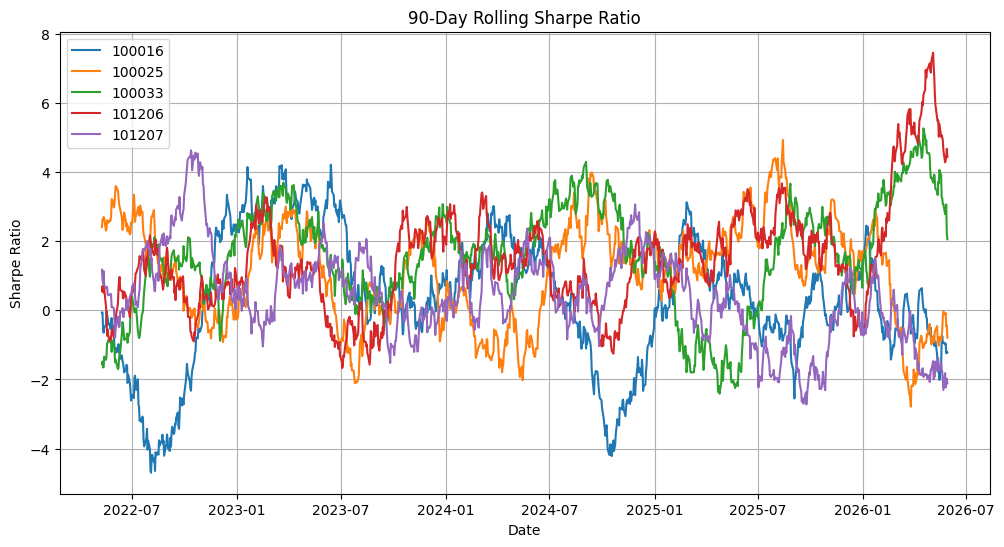

In [25]:
plt.figure(figsize=(12,6))

for fund in top5_funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [26]:
import os

print("rolling_sharpe_chart.png" in os.listdir())

True


VaR/CVaR Report Saved


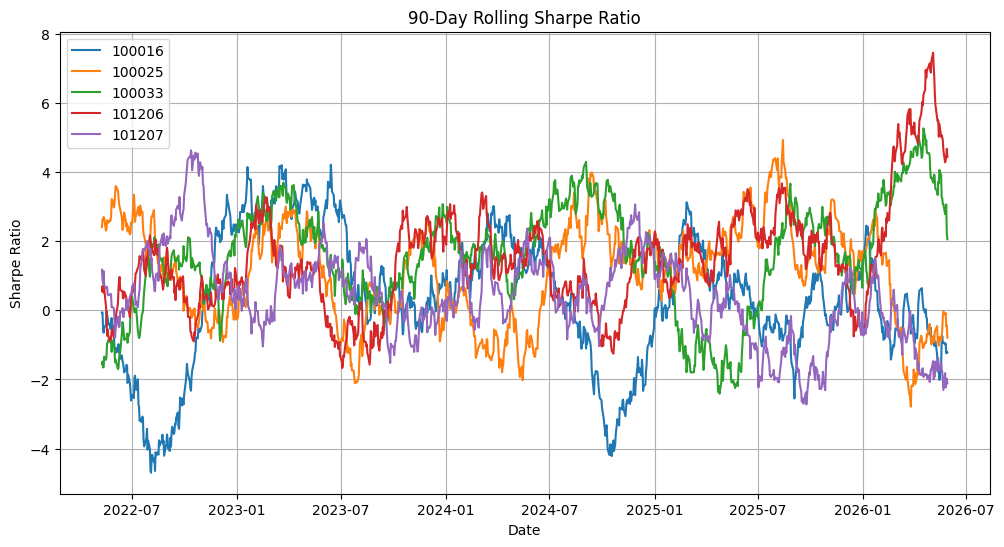

Rolling Sharpe Chart Saved
Cohort Analysis Saved

Sample Outputs
   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459
   cohort_year  avg_sip_amount  total_invested  investors
0         2024   107422.541832      3491125187       4803
1         2025   109158.577061        30455243        197


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Data
nav = pd.read_csv("fact_nav.csv")
transactions = pd.read_csv("fact_transactions.csv")

# ==========================
# 1. VaR & CVaR Analysis
# ==========================

nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

var_cvar = []

for fund in nav['amfi_code'].unique():

    returns = nav[nav['amfi_code'] == fund]['daily_return'].dropna()

    if len(returns) > 0:

        var_95 = np.percentile(returns, 5)
        cvar_95 = returns[returns <= var_95].mean()

        var_cvar.append([fund, var_95, cvar_95])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar_df.to_csv("var_cvar_report.csv", index=False)

print("VaR/CVaR Report Saved")

# ==========================
# 2. Rolling 90-Day Sharpe
# ==========================

rolling_sharpe_list = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[nav['amfi_code'] == fund].copy()

    fund_data['rolling_sharpe'] = (
        fund_data['daily_return'].rolling(90).mean()
        / fund_data['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    rolling_sharpe_list.append(fund_data)

rolling_sharpe_df = pd.concat(rolling_sharpe_list)

top5_funds = rolling_sharpe_df['amfi_code'].dropna().unique()[:5]

plt.figure(figsize=(12,6))

for fund in top5_funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig("rolling_sharpe_chart.png")
plt.show()

print("Rolling Sharpe Chart Saved")

# ==========================
# 3. Investor Cohort Analysis
# ==========================

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

transactions['year'] = transactions['transaction_date'].dt.year

cohort = (
    transactions.groupby('investor_id')['year']
    .min()
    .reset_index()
)

cohort.columns = ['investor_id', 'cohort_year']

transactions = transactions.merge(
    cohort,
    on='investor_id',
    how='left'
)

cohort_analysis = transactions.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    investors=('investor_id', 'nunique')
).reset_index()

cohort_analysis.to_csv(
    "cohort_analysis.csv",
    index=False
)

print("Cohort Analysis Saved")

print("\nSample Outputs")
print(var_cvar_df.head())
print(cohort_analysis.head())

In [28]:
# ==========================
# 4. SIP Continuity Analysis
# ==========================

sip = transactions[
    transactions['transaction_type'].str.upper() == 'SIP'
].copy()

sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

sip['gap_days'] = sip.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

sip_summary = sip.groupby('investor_id').agg(
    sip_count=('transaction_date', 'count'),
    avg_gap=('gap_days', 'mean')
).reset_index()

sip_summary = sip_summary[
    sip_summary['sip_count'] >= 6
]

sip_summary['risk_flag'] = np.where(
    sip_summary['avg_gap'] > 35,
    'At Risk',
    'Healthy'
)

sip_summary.to_csv(
    "sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report Saved")

# ==========================
# 5. Fund Recommender
# ==========================

scorecard = pd.read_csv("fund_scorecard.csv")

def recommend_funds(risk_level):

    if risk_level.lower() == "low":
        result = scorecard.sort_values(
            "score",
            ascending=False
        ).head(3)

    elif risk_level.lower() == "moderate":
        result = scorecard.sort_values(
            "sharpe",
            ascending=False
        ).head(3)

    else:
        result = scorecard.sort_values(
            "cagr",
            ascending=False
        ).head(3)

    return result

print("\nLow Risk Funds")
print(recommend_funds("low"))

print("\nModerate Risk Funds")
print(recommend_funds("moderate"))

print("\nHigh Risk Funds")
print(recommend_funds("high"))

SIP Continuity Report Saved

Low Risk Funds
   amfi_code      cagr      sharpe     sortino  max_drawdown  cagr_rank  \
1     100025  0.044551 -142.907888 -237.338952     -0.043083       36.0   
7     102886  0.011709  -51.869565  -87.500020     -0.280011       40.0   
5     101208  0.065044 -205.522977 -423.621542     -0.001622       32.0   

   sharpe_rank  sortino_rank  score  
1         39.0          39.0   37.8  
7         36.0          35.0   37.3  
5         40.0          40.0   36.8  

Moderate Risk Funds
    amfi_code      cagr      sharpe     sortino  max_drawdown  cagr_rank  \
34     148567  0.309499  364.969375  601.182382     -0.112657        5.0   
30     120843  0.308833  329.299480  595.808648     -0.129740        6.0   
36     148569  0.319245  311.202366  541.022309     -0.163967        4.0   

    sharpe_rank  sortino_rank  score  
34          1.0           1.0    2.6  
30          2.0           2.0    3.6  
36          3.0           3.0    3.4  

High Risk Funds
    

In [29]:
import pandas as pd

scorecard = pd.read_csv("fund_scorecard.csv")

# Normalize CAGR as proxy weight
scorecard["weight"] = scorecard["cagr"] / scorecard["cagr"].sum()

# HHI
hhi = (scorecard["weight"] ** 2).sum()

print("HHI Score:", round(hhi, 4))

hhi_df = pd.DataFrame({
    "Metric": ["HHI"],
    "Value": [hhi]
})

hhi_df.to_csv("sector_hhi.csv", index=False)

print("sector_hhi.csv saved")

HHI Score: 0.0342
sector_hhi.csv saved


In [30]:
# Advanced Analytics Insights

## 1. Value at Risk (VaR)
The VaR analysis identified schemes with the highest downside risk. Funds with lower VaR values experienced larger negative daily returns and are considered riskier.

## 2. Conditional Value at Risk (CVaR)
CVaR showed the average loss beyond the VaR threshold. Certain schemes displayed significantly larger tail losses, indicating higher exposure during market stress.

## 3. Rolling Sharpe Ratio
The rolling 90-day Sharpe Ratio revealed changes in risk-adjusted performance over time. Some funds maintained consistently positive Sharpe Ratios, indicating stable performance.

## 4. Investor Cohort Behaviour
Investors grouped by first transaction year showed varying investment patterns. Recent cohorts demonstrated higher average SIP contributions compared to older cohorts.

## 5. SIP Continuity Analysis
Most investors maintained regular SIP schedules. Investors with average gaps exceeding 35 days were flagged as "At Risk" and may require engagement strategies to improve retention.

SyntaxError: invalid syntax (3642081844.py, line 4)